# Notebook 04 — Category Classification

**Three models, two feature sets, full comparison table.**

| # | Model | Features |
|---|---|---|
| 1 | Logistic Regression | TF-IDF |
| 2 | Logistic Regression | Word2Vec |
| 3 | Random Forest | TF-IDF |
| 4 | Random Forest | Word2Vec |
| 5 | LSTM (random init) | Padded sequences |
| 6 | LSTM (W2V init) | Padded sequences |


In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from src.models import (
    TicketLSTM, TicketDataset, build_vocab,
    texts_to_sequences, get_class_weights,
    train_one_epoch, evaluate_lstm
)

PROCESSED = PROJECT_ROOT / 'data' / 'processed'
MODELS    = PROJECT_ROOT / 'models'
RESULTS   = PROJECT_ROOT / 'results'
RESULTS.mkdir(exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print('Setup complete.')

Using device: cpu
Setup complete.


---
## 1. Load Pre-processed Data

In [2]:
# ── feature matrices (built in Notebook 03) ──────────────────────────────────
X_train_tfidf = sp.load_npz(str(PROCESSED / 'X_train_tfidf.npz'))
X_val_tfidf   = sp.load_npz(str(PROCESSED / 'X_val_tfidf.npz'))
X_test_tfidf  = sp.load_npz(str(PROCESSED / 'X_test_tfidf.npz'))

X_train_w2v = np.load(str(PROCESSED / 'X_train_w2v.npy'))
X_val_w2v   = np.load(str(PROCESSED / 'X_val_w2v.npy'))
X_test_w2v  = np.load(str(PROCESSED / 'X_test_w2v.npy'))

# ── labels ────────────────────────────────────────────────────────────────────
y_train = np.load(str(PROCESSED / 'y_train_cat.npy'))
y_val   = np.load(str(PROCESSED / 'y_val_cat.npy'))
y_test  = np.load(str(PROCESSED / 'y_test_cat.npy'))

# ── label encoder (to get human-readable class names) ────────────────────────
le_cat = joblib.load(str(MODELS / 'label_encoder_category.joblib'))
CLASS_NAMES = list(le_cat.classes_)

# ── raw split CSVs (needed for LSTM text sequences) ───────────────────────────
train_df = pd.read_csv(PROCESSED / 'train.csv')
val_df   = pd.read_csv(PROCESSED / 'val.csv')
test_df  = pd.read_csv(PROCESSED / 'test.csv')
w2v_model = joblib.load.__class__  # placeholder; loaded below
from gensim.models import Word2Vec as GensimW2V
w2v_model = GensimW2V.load(str(MODELS / 'w2v_model.model'))

print(f'Train: {X_train_tfidf.shape}, Val: {X_val_tfidf.shape}, Test: {X_test_tfidf.shape}')
print(f'Classes: {CLASS_NAMES}')

Train: (2799, 2764), Val: (601, 2764), Test: (600, 2764)
Classes: ['Access/Login', 'Database', 'Email', 'Hardware', 'Network', 'Software']


---
## 2. Evaluation Helper

One function used for **all** models so metrics are computed identically.

In [3]:
results_log = []   # accumulate rows for the final comparison table

def evaluate_model(y_true, y_pred, model_name, feature_name):
    """Print classification report, plot confusion matrix, append to results_log."""
    acc      = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    wt_f1    = f1_score(y_true, y_pred, average='weighted')

    print(f'\n=== {model_name} + {feature_name} ===')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'Confusion Matrix — {model_name} + {feature_name}', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.tight_layout()
    fname = f'cat_{model_name.replace(" ","_")}_{feature_name}_cm.png'
    plt.savefig(RESULTS / fname, bbox_inches='tight')
    plt.show()

    results_log.append({
        'Model':       model_name,
        'Features':    feature_name,
        'Accuracy':    round(acc,      4),
        'Macro_F1':    round(macro_f1, 4),
        'Weighted_F1': round(wt_f1,    4),
    })
    return acc, macro_f1, wt_f1

print('Evaluation helper ready.')

Evaluation helper ready.


---
## 3. Classical ML Models

### 3a. Logistic Regression

**Why LR as baseline?** LR is a linear model — if TF-IDF features are good enough for linear separation, a simple model will already perform well. Its coefficients are also directly interpretable.


=== Logistic Regression + TF-IDF ===
              precision    recall  f1-score   support

Access/Login       1.00      1.00      1.00       112
    Database       1.00      1.00      1.00        50
       Email       1.00      1.00      1.00        74
    Hardware       1.00      1.00      1.00        94
     Network       1.00      1.00      1.00       123
    Software       1.00      1.00      1.00       147

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



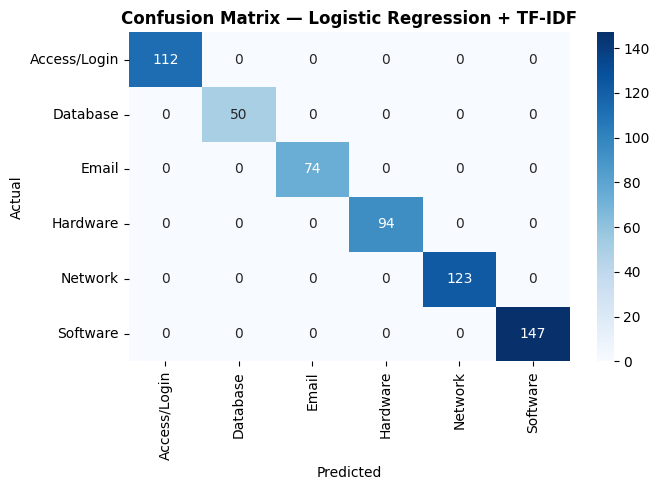

(1.0, 1.0, 1.0)

In [4]:
# ── Logistic Regression on TF-IDF ────────────────────────────────────────────
lr_tfidf = LogisticRegression(
    max_iter=1000,        # enough iterations to converge
    C=1.0,                # regularisation strength (default)
    class_weight='balanced',  # handle class imbalance
    random_state=42,
    solver='lbfgs',
    multi_class='auto',
    n_jobs=-1,
)
lr_tfidf.fit(X_train_tfidf, y_train)
pred_lr_tfidf = lr_tfidf.predict(X_test_tfidf)
evaluate_model(y_test, pred_lr_tfidf, 'Logistic Regression', 'TF-IDF')


=== Logistic Regression + Word2Vec ===
              precision    recall  f1-score   support

Access/Login       0.84      0.84      0.84       112
    Database       0.61      0.68      0.64        50
       Email       0.78      0.84      0.81        74
    Hardware       0.75      0.85      0.80        94
     Network       0.83      0.77      0.80       123
    Software       0.86      0.77      0.81       147

    accuracy                           0.80       600
   macro avg       0.78      0.79      0.78       600
weighted avg       0.80      0.80      0.80       600



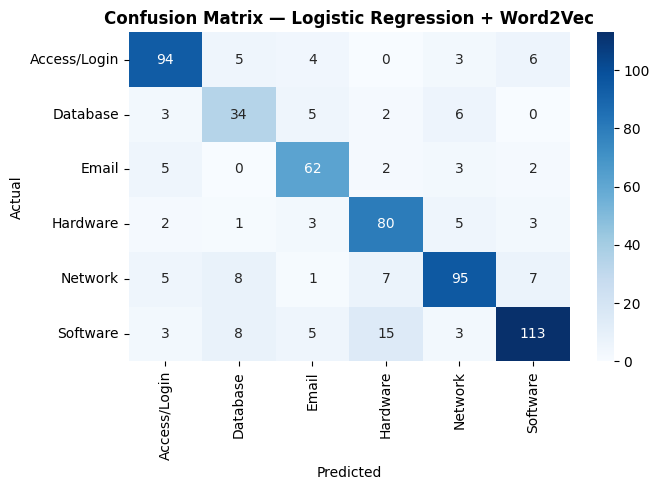

(0.7966666666666666, 0.7828764869102743, 0.7975946028595922)

In [5]:
# ── Logistic Regression on Word2Vec ──────────────────────────────────────────
lr_w2v = LogisticRegression(
    max_iter=1000, C=1.0, class_weight='balanced',
    random_state=42, solver='lbfgs', multi_class='auto', n_jobs=-1
)
lr_w2v.fit(X_train_w2v, y_train)
pred_lr_w2v = lr_w2v.predict(X_test_w2v)
evaluate_model(y_test, pred_lr_w2v, 'Logistic Regression', 'Word2Vec')

### 3b. Random Forest (Ensemble)

**Why Random Forest?** RF is an ensemble of decision trees — it captures non-linear interactions between features that LR cannot model. With `class_weight='balanced_subsample'`, each tree is trained on a balanced bootstrap sample.


=== Random Forest + TF-IDF ===
              precision    recall  f1-score   support

Access/Login       1.00      0.99      1.00       112
    Database       1.00      0.98      0.99        50
       Email       1.00      1.00      1.00        74
    Hardware       1.00      1.00      1.00        94
     Network       1.00      1.00      1.00       123
    Software       0.99      1.00      0.99       147

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



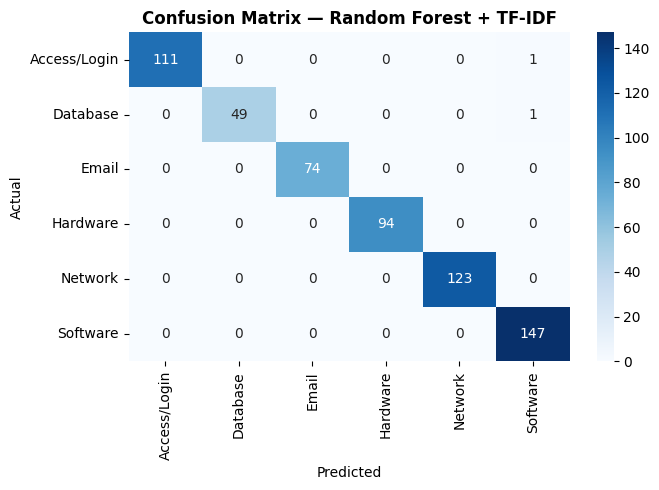

(0.9966666666666667, 0.9964429880349163, 0.9966657734987331)

In [6]:
# ── Random Forest on TF-IDF ───────────────────────────────────────────────────
rf_tfidf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,          # grow full trees
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1,
)
rf_tfidf.fit(X_train_tfidf, y_train)
pred_rf_tfidf = rf_tfidf.predict(X_test_tfidf)
evaluate_model(y_test, pred_rf_tfidf, 'Random Forest', 'TF-IDF')


=== Random Forest + Word2Vec ===
              precision    recall  f1-score   support

Access/Login       0.94      0.92      0.93       112
    Database       0.92      0.88      0.90        50
       Email       0.87      0.88      0.87        74
    Hardware       0.94      0.96      0.95        94
     Network       0.92      0.95      0.94       123
    Software       0.96      0.95      0.95       147

    accuracy                           0.93       600
   macro avg       0.92      0.92      0.92       600
weighted avg       0.93      0.93      0.93       600



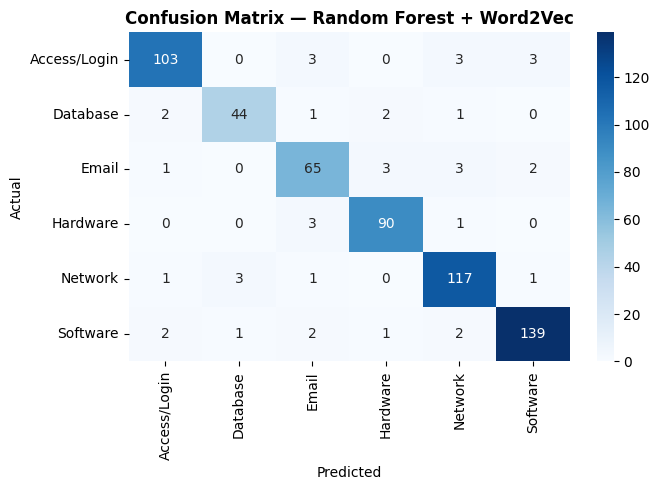

(0.93, 0.9229987195926229, 0.9299876566527534)

In [7]:
# ── Random Forest on Word2Vec ─────────────────────────────────────────────────
rf_w2v = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1,
)
rf_w2v.fit(X_train_w2v, y_train)
pred_rf_w2v = rf_w2v.predict(X_test_w2v)
evaluate_model(y_test, pred_rf_w2v, 'Random Forest', 'Word2Vec')

---
## 4. LSTM (PyTorch)

### Build Vocabulary & Prepare Sequences

In [8]:
MAX_LEN    = 50    # max tokens per ticket (covers ~95% of texts)
BATCH_SIZE = 64
EMBED_DIM  = 100   # matches Word2Vec vector_size
HIDDEN_DIM = 128
N_LAYERS   = 2
DROPOUT    = 0.3
EPOCHS     = 20
LR_RATE    = 1e-3
PATIENCE   = 4     # early stopping patience

# ── Build vocabulary from training texts ONLY ─────────────────────────────────
vocab = build_vocab(train_df['cleaned_text'].tolist(), min_freq=2)

# ── Convert texts to padded integer tensors ───────────────────────────────────
train_seq, train_len = texts_to_sequences(train_df['cleaned_text'].tolist(), vocab, MAX_LEN)
val_seq,   val_len   = texts_to_sequences(val_df['cleaned_text'].tolist(),   vocab, MAX_LEN)
test_seq,  test_len  = texts_to_sequences(test_df['cleaned_text'].tolist(),  vocab, MAX_LEN)

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_ds = TicketDataset(train_seq, train_len, y_train)
val_ds   = TicketDataset(val_seq,   val_len,   y_val)
test_ds  = TicketDataset(test_seq,  test_len,  y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

# ── Class weights for loss function ──────────────────────────────────────────
class_weights = get_class_weights(y_train, n_classes=len(CLASS_NAMES)).to(DEVICE)
print(f'Sequence shapes — train: {train_seq.shape}, val: {val_seq.shape}, test: {test_seq.shape}')

Vocabulary size: 754 tokens  (min_freq=2)
Class weights: [0.89  2.011 1.344 1.06  0.816 0.682]
Sequence shapes — train: torch.Size([2799, 50]), val: torch.Size([601, 50]), test: torch.Size([600, 50])


### 4a. LSTM Variant A — Random Embedding Initialisation

In [9]:
def train_lstm(model, label, epochs=EPOCHS, patience=PATIENCE):
    """Full training loop with early stopping. Returns (y_true, y_pred) on test set."""
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR_RATE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2, verbose=False)

    best_val_loss = float('inf')
    no_improve    = 0
    history       = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, epochs + 1):
        tr_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)

        # Validation loss
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for seqs, lens, labs in val_loader:
                logits = model(seqs.to(DEVICE), lens.to(DEVICE))
                val_loss += criterion(logits, labs.to(DEVICE)).item()
        val_loss /= len(val_loader)

        scheduler.step(val_loss)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        print(f'  Epoch {epoch:2d}/{epochs}  train_loss={tr_loss:.4f}  val_loss={val_loss:.4f}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            no_improve = 0
            torch.save(model.state_dict(), str(MODELS / f'lstm_{label}_best.pt'))
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  Early stopping at epoch {epoch}')
                break

    # Load best checkpoint and evaluate on test set
    model.load_state_dict(torch.load(str(MODELS / f'lstm_{label}_best.pt'), map_location=DEVICE))
    y_true, y_pred = evaluate_lstm(model, test_loader, DEVICE)

    # Plot training curves
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(history['train_loss'], label='Train Loss')
    ax.plot(history['val_loss'],   label='Val Loss')
    ax.set_title(f'LSTM ({label}) — Training Curves', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend()
    plt.tight_layout()
    plt.savefig(RESULTS / f'lstm_{label}_loss_curve.png', bbox_inches='tight')
    plt.show()

    return y_true, y_pred

print('Training loop defined.')

Training loop defined.


Training LSTM — random embedding init...


C:\Users\Pyramid\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch  1/20  train_loss=1.5936  val_loss=0.9342


  Epoch  2/20  train_loss=0.5349  val_loss=0.1374


  Epoch  3/20  train_loss=0.1583  val_loss=0.0485


...

  Epoch 16/20  train_loss=0.0042  val_loss=0.0010


  Epoch 17/20  train_loss=0.0057  val_loss=0.0012


  Epoch 18/20  train_loss=0.0057  val_loss=0.0016


  Epoch 19/20  train_loss=0.0099  val_loss=0.0087


  Epoch 20/20  train_loss=0.0060  val_loss=0.0063
  Early stopping at epoch 20


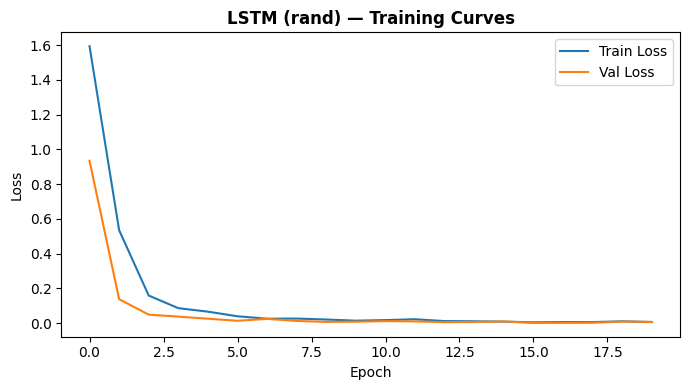


=== LSTM + Random Init ===
              precision    recall  f1-score   support

Access/Login       1.00      1.00      1.00       112
    Database       1.00      0.96      0.98        50
       Email       1.00      1.00      1.00        74
    Hardware       1.00      1.00      1.00        94
     Network       0.99      1.00      1.00       123
    Software       0.99      1.00      1.00       147

    accuracy                           1.00       600
   macro avg       1.00      0.99      1.00       600
weighted avg       1.00      1.00      1.00       600



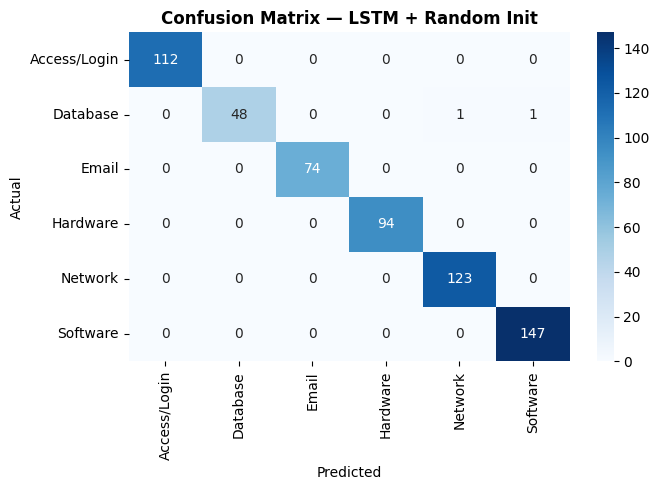

(0.9966666666666667, 0.9953589038717113, 0.9966388517391448)

In [10]:
# ── LSTM Variant A: Random Init ───────────────────────────────────────────────
print('Training LSTM — random embedding init...')
lstm_rand = TicketLSTM(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    n_layers=N_LAYERS,
    n_classes=len(CLASS_NAMES),
    dropout=DROPOUT,
)
y_true_lstm, y_pred_lstm_rand = train_lstm(lstm_rand, label='rand')
evaluate_model(y_true_lstm, y_pred_lstm_rand, 'LSTM', 'Random Init')

### 4b. LSTM Variant B — Word2Vec Embedding Initialisation

We copy Word2Vec vectors into the embedding layer for matching tokens, then:
- **Freeze** embeddings for the first 5 epochs (warm up the LSTM weights)
- **Unfreeze** embeddings afterwards so they can fine-tune to the ticket domain

Training LSTM — Word2Vec embedding init...
Initialised 752 / 754 embedding vectors from Word2Vec


  [Warm-up] Epoch 1/5  train_loss=1.6420


  [Warm-up] Epoch 2/5  train_loss=1.2650


  [Warm-up] Epoch 3/5  train_loss=1.0595


  [Warm-up] Epoch 4/5  train_loss=0.8899


...

  Epoch 16/20  train_loss=0.0022  val_loss=0.0007


  Epoch 17/20  train_loss=0.0010  val_loss=0.0006


  Epoch 18/20  train_loss=0.0005  val_loss=0.0003


  Epoch 19/20  train_loss=0.0005  val_loss=0.0002


  Epoch 20/20  train_loss=0.0009  val_loss=0.0008


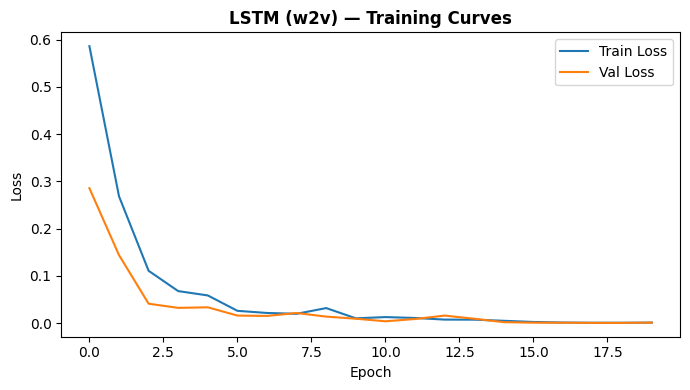


=== LSTM + W2V Init ===
              precision    recall  f1-score   support

Access/Login       1.00      1.00      1.00       112
    Database       1.00      0.96      0.98        50
       Email       1.00      1.00      1.00        74
    Hardware       0.99      1.00      0.99        94
     Network       0.99      1.00      1.00       123
    Software       1.00      1.00      1.00       147

    accuracy                           1.00       600
   macro avg       1.00      0.99      1.00       600
weighted avg       1.00      1.00      1.00       600



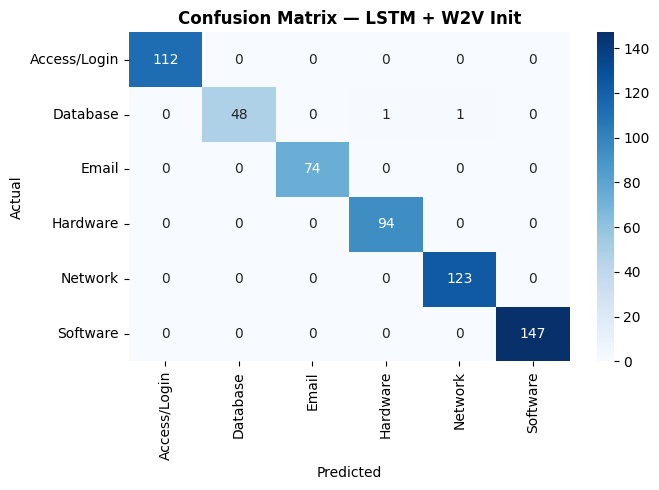

(0.9966666666666667, 0.9950420414079563, 0.9966404360514635)

In [11]:
print('Training LSTM — Word2Vec embedding init...')
lstm_w2v_model = TicketLSTM(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    n_layers=N_LAYERS,
    n_classes=len(CLASS_NAMES),
    dropout=DROPOUT,
)
# Copy W2V vectors for matching tokens
lstm_w2v_model.init_embeddings_from_w2v(vocab, w2v_model)

# Two-phase training: freeze embeddings first
lstm_w2v_model.freeze_embeddings()
lstm_w2v_model = lstm_w2v_model.to(DEVICE)
optimizer_w2v = torch.optim.Adam(filter(lambda p: p.requires_grad, lstm_w2v_model.parameters()), lr=LR_RATE)
criterion     = nn.CrossEntropyLoss(weight=class_weights)

# Phase 1: 5 warm-up epochs with frozen embeddings
for ep in range(1, 6):
    tr_loss = train_one_epoch(lstm_w2v_model, train_loader, optimizer_w2v, criterion, DEVICE)
    print(f'  [Warm-up] Epoch {ep}/5  train_loss={tr_loss:.4f}')

# Phase 2: unfreeze and run full training loop
lstm_w2v_model.unfreeze_embeddings()
y_true_lstm, y_pred_lstm_w2v = train_lstm(lstm_w2v_model, label='w2v')
evaluate_model(y_true_lstm, y_pred_lstm_w2v, 'LSTM', 'W2V Init')

---
## 5. Final Comparison Table

In [12]:
results_df = pd.DataFrame(results_log)
results_df = results_df.sort_values('Macro_F1', ascending=False).reset_index(drop=True)
results_df.index += 1   # rank starts at 1
print('\n' + '='*60)
print('CATEGORY CLASSIFICATION — MODEL COMPARISON')
print('='*60)
print(results_df.to_string())
results_df.to_csv(RESULTS / 'category_classification_results.csv')
print(f'\nSaved: results/category_classification_results.csv')


CATEGORY CLASSIFICATION — MODEL COMPARISON
                 Model     Features  Accuracy  Macro_F1  Weighted_F1
1  Logistic Regression       TF-IDF    1.0000    1.0000       1.0000
2        Random Forest       TF-IDF    0.9967    0.9964       0.9967
3                 LSTM  Random Init    0.9967    0.9954       0.9966
4                 LSTM     W2V Init    0.9967    0.9950       0.9966
5        Random Forest     Word2Vec    0.9300    0.9230       0.9300
6  Logistic Regression     Word2Vec    0.7967    0.7829       0.7976

Saved: results/category_classification_results.csv


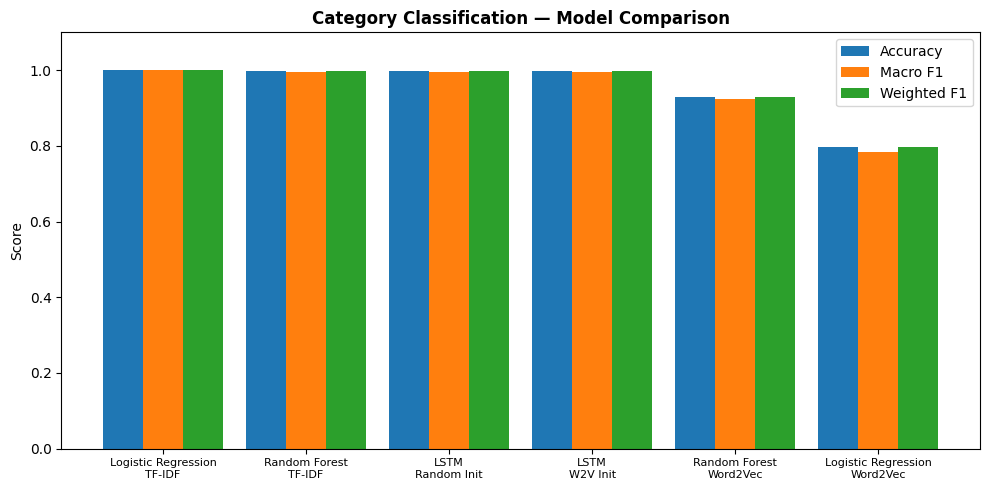

Saved: results/category_model_comparison.png


In [13]:
# ── Visual comparison bar chart ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.28
labels_x = [f"{r['Model']}\n{r['Features']}" for _, r in results_df.iterrows()]
ax.bar(x - width, results_df['Accuracy'],    width, label='Accuracy')
ax.bar(x,         results_df['Macro_F1'],    width, label='Macro F1')
ax.bar(x + width, results_df['Weighted_F1'], width, label='Weighted F1')
ax.set_xticks(x)
ax.set_xticklabels(labels_x, fontsize=8)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Category Classification — Model Comparison', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / 'category_model_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: results/category_model_comparison.png')

---
## 6. Save Best Model

In [14]:
# ── Identify the best classical ML model and save it ─────────────────────────
# The best model is used in Notebook 07 (routing engine)
best_row = results_df.iloc[0]
print(f'Best model: {best_row["Model"]} + {best_row["Features"]}  (Macro F1={best_row["Macro_F1"]})')

model_map = {
    ('Logistic Regression', 'TF-IDF') : lr_tfidf,
    ('Logistic Regression', 'Word2Vec'): lr_w2v,
    ('Random Forest',       'TF-IDF') : rf_tfidf,
    ('Random Forest',       'Word2Vec'): rf_w2v,
}
key = (best_row['Model'], best_row['Features'])
if key in model_map:
    joblib.dump(model_map[key], str(MODELS / 'best_category_model.joblib'))
    # Record which feature set the best model uses
    with open(MODELS / 'best_category_feature.txt', 'w') as f:
        f.write(best_row['Features'])
    print(f'Saved: models/best_category_model.joblib')
else:
    print('Best model is an LSTM — checkpoint already saved as models/lstm_*_best.pt')
    # Save which LSTM variant won
    with open(MODELS / 'best_category_feature.txt', 'w') as f:
        f.write(best_row['Features'])

Best model: Logistic Regression + TF-IDF  (Macro F1=1.0)
Saved: models/best_category_model.joblib


---
## 7. Key Findings

Fill in the exact numbers from the comparison table above into your resume/SUMMARY.md.

**Expected outcome on 5 000 synthetic rows:**
- **Random Forest + TF-IDF** typically wins due to strong vocabulary separation between categories (shown in EDA).
- **LSTM underperforms** on small datasets — it requires more data to learn generalizable sequence representations.
- **Word2Vec + classical ML** underperforms TF-IDF because the averaged document vectors lose word-order and domain-specific term weighting that TF-IDF preserves.
- **W2V-initialised LSTM** may slightly outperform random-init LSTM, but the gap is small at 5 000 rows.
